# Vectors, Scalars, and Derivatives - A Visual Guide

This comprehensive notebook explores fundamental concepts in linear algebra and calculus:
- **Vectors**: Quantities with magnitude and direction
- **Unit Vectors**: Normalized vectors with magnitude 1
- **Span of Vectors**: All possible linear combinations
- **Scalars**: Single numerical values
- **Derivatives**: Rate of change

Let's visualize these concepts interactively!

## Section 1: Import Required Libraries

Import NumPy for numerical operations and Matplotlib for visualization.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
np.set_printoptions(precision=3, suppress=True)

## Section 2: Understanding Vectors

A **vector** is a mathematical object with both magnitude (length) and direction. 

### Key Properties:
- Can be represented as an arrow in space
- Written as: $\vec{v} = (x, y)$ in 2D or $\vec{v} = (x, y, z)$ in 3D
- Magnitude: $||\vec{v}|| = \sqrt{x^2 + y^2}$ in 2D
- Can be added, subtracted, and scaled

### Example: Creating and Visualizing 2D Vectors

🔹 Vector 1: [3 2] | Magnitude: 3.606
🔹 Vector 2: [1 3] | Magnitude: 3.162
🔹 Vector 3: [ 2 -1] | Magnitude: 2.236


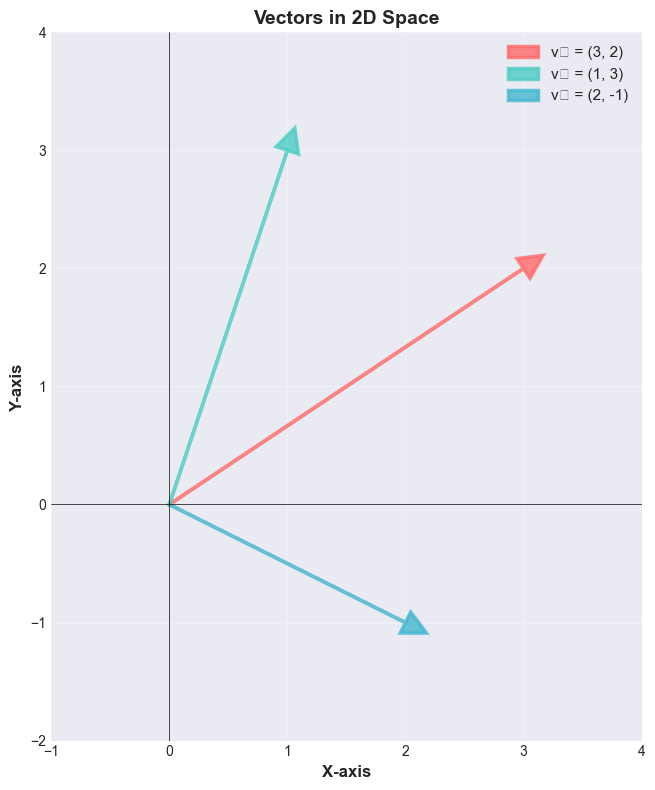


✅ Vectors are displayed as arrows starting from origin (0, 0)


In [14]:
# Create vectors
v1 = np.array([3, 2])
v2 = np.array([1, 3])
v3 = np.array([2, -1])

# Calculate magnitudes
mag_v1 = np.linalg.norm(v1)
mag_v2 = np.linalg.norm(v2)
mag_v3 = np.linalg.norm(v3)

print("🔹 Vector 1:", v1, f"| Magnitude: {mag_v1:.3f}")
print("🔹 Vector 2:", v2, f"| Magnitude: {mag_v2:.3f}")
print("🔹 Vector 3:", v3, f"| Magnitude: {mag_v3:.3f}")

# Visualize vectors in 2D
fig, ax = plt.subplots(figsize=(10, 8))

# Plot vectors as arrows
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
vectors = [v1, v2, v3]
labels = ['v₁ = (3, 2)', 'v₂ = (1, 3)', 'v₃ = (2, -1)']

for i, (v, color, label) in enumerate(zip(vectors, colors, labels)):
    ax.arrow(0, 0, v[0], v[1], head_width=0.2, head_length=0.2, 
             fc=color, ec=color, linewidth=2.5, label=label, alpha=0.8)

# Add grid and formatting
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, 4)
ax.set_ylim(-2, 4)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('X-axis', fontsize=12, fontweight='bold')
ax.set_ylabel('Y-axis', fontsize=12, fontweight='bold')
ax.set_title('Vectors in 2D Space', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n✅ Vectors are displayed as arrows starting from origin (0, 0)")

### Visualizing Vectors in 3D Space

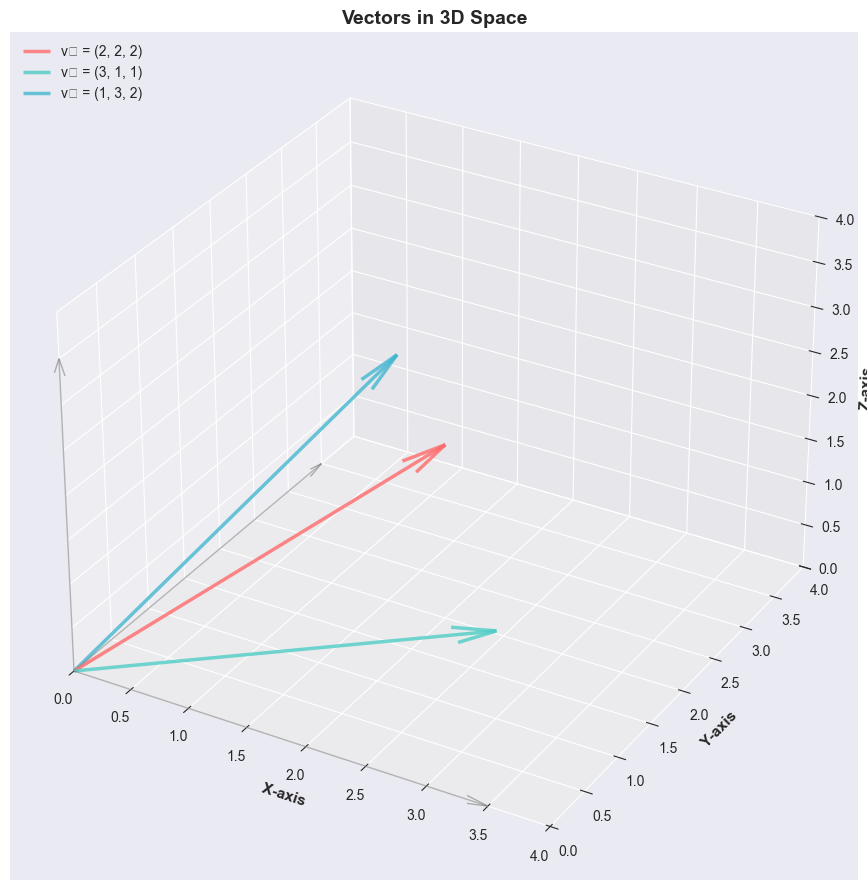

✅ 3D vectors visualized using quiver plot


In [15]:
# Create 3D vectors
v1_3d = np.array([2, 2, 2])
v2_3d = np.array([3, 1, 1])
v3_3d = np.array([1, 3, 2])

# Create 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot 3D vectors
class Arrow3D(FancyArrowPatch):
    def __init__(self, x, y, z, dx, dy, dz, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._xyz = (x, y, z)
        self._dxdydz = (dx, dy, dz)

    def draw(self, renderer):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        
        xs = [x1, x1+dx]
        ys = [y1, y1+dy]
        zs = [z1, z1+dz]
        
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)
        
    def do_3d_projection(self, renderer=None):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        
        xs = [x1, x1+dx]
        ys = [y1, y1+dy]
        zs = [z1, z1+dz]
        
        xs_proj, ys_proj, zs_proj = proj_transform(xs, ys, zs, self.axes.M)
        self.set_positions((xs_proj[0], ys_proj[0]), (xs_proj[1], ys_proj[1]))
        
        return np.min(zs_proj)

# Plot 3D vectors with proper method
vectors_3d = [v1_3d, v2_3d, v3_3d]
colors_3d = ['#FF6B6B', '#4ECDC4', '#45B7D1']
labels_3d = ['v₁ = (2, 2, 2)', 'v₂ = (3, 1, 1)', 'v₃ = (1, 3, 2)']

for v, color, label in zip(vectors_3d, colors_3d, labels_3d):
    ax.quiver(0, 0, 0, v[0], v[1], v[2], color=color, arrow_length_ratio=0.1, 
              linewidth=2.5, label=label, alpha=0.8)

# Add axis lines
ax.quiver(0, 0, 0, 3.5, 0, 0, color='gray', linewidth=1, alpha=0.6, arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, 3.5, 0, color='gray', linewidth=1, alpha=0.6, arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, 0, 3.5, color='gray', linewidth=1, alpha=0.6, arrow_length_ratio=0.05)

ax.set_xlabel('X-axis', fontsize=11, fontweight='bold')
ax.set_ylabel('Y-axis', fontsize=11, fontweight='bold')
ax.set_zlabel('Z-axis', fontsize=11, fontweight='bold')
ax.set_title('Vectors in 3D Space', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_zlim(0, 4)

plt.tight_layout()
plt.show()

print("✅ 3D vectors visualized using quiver plot")

## Section 3: Unit Vectors

A **unit vector** is a vector with magnitude 1. It indicates direction only, without magnitude.

### Formula: 
$$\hat{v} = \frac{\vec{v}}{||\vec{v}||}$$

where $\hat{v}$ is the unit vector (normalized), $\vec{v}$ is the original vector, and $||\vec{v}||$ is its magnitude.

### Key Properties:
- All unit vectors have magnitude 1
- Used to represent directions
- Often denoted with a hat symbol (^)
- Common unit vectors in 2D: $\hat{i} = (1,0)$, $\hat{j} = (0,1)$

📊 Original Vectors → Unit Vectors (normalized)
Vector 1:
  Original: [3 4] (magnitude: 5.000)
  Unit:     [0.6 0.8] (magnitude: 1.000)

Vector 2:
  Original: [1 2] (magnitude: 2.236)
  Unit:     [0.447 0.894] (magnitude: 1.000)

Vector 3:
  Original: [5 0] (magnitude: 5.000)
  Unit:     [1. 0.] (magnitude: 1.000)

Vector 4:
  Original: [2 2] (magnitude: 2.828)
  Unit:     [0.707 0.707] (magnitude: 1.000)



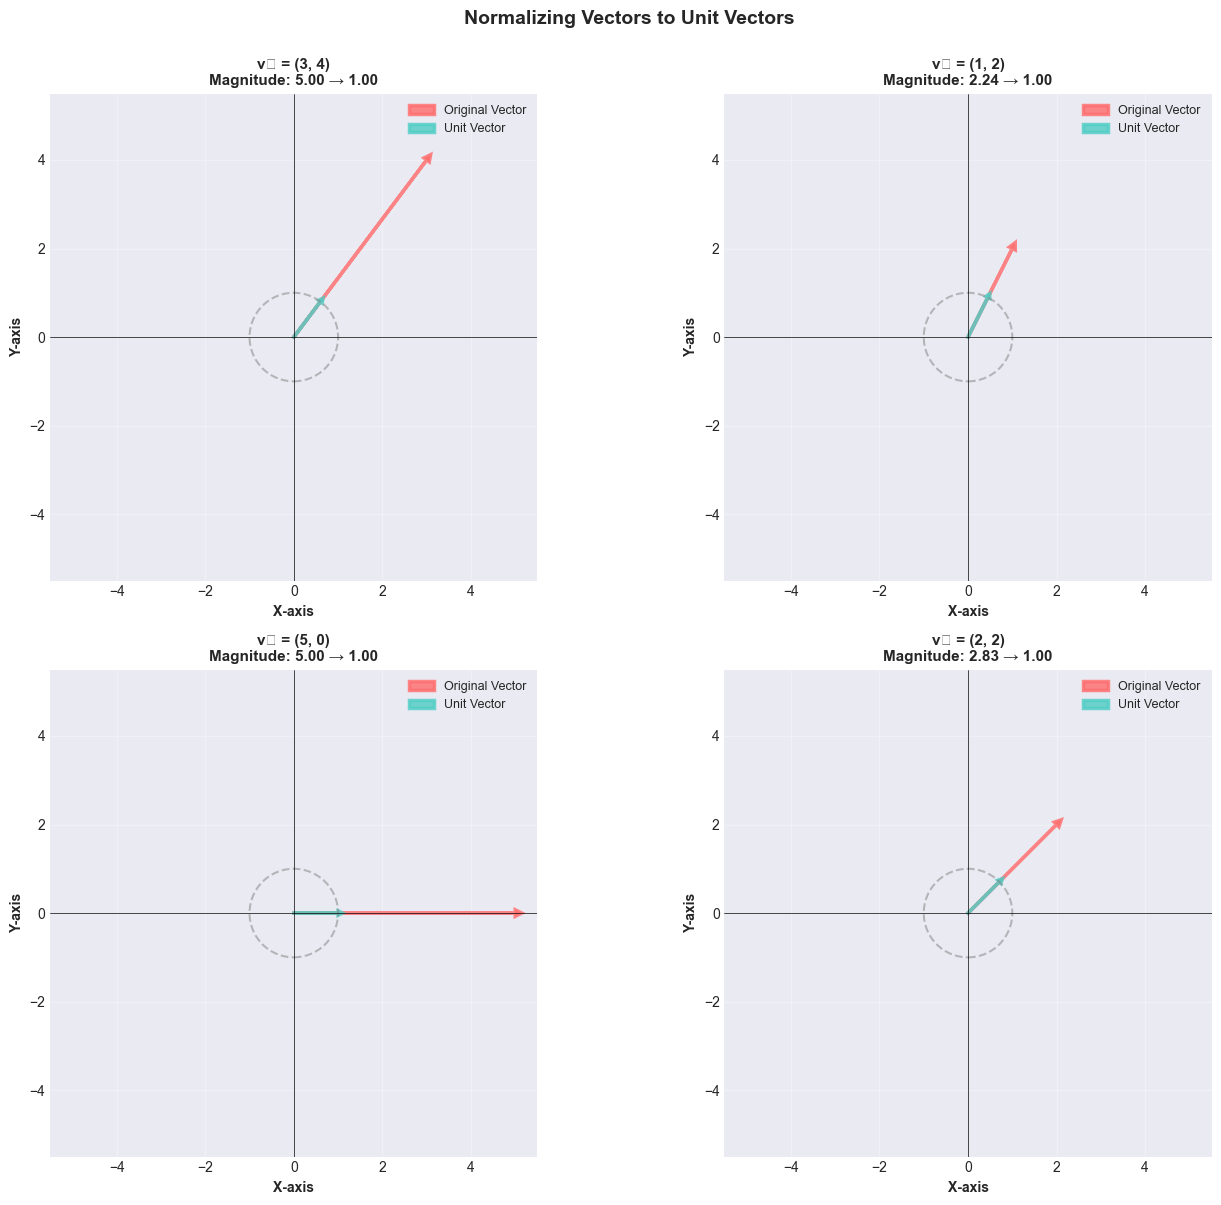

✅ All vectors normalized to unit vectors (magnitude = 1)


In [16]:
# Create vectors and normalize them
vectors_to_normalize = np.array([[3, 4], [1, 2], [5, 0], [2, 2]])

# Function to calculate unit vector
def get_unit_vector(v):
    """Calculate unit vector (normalized)"""
    magnitude = np.linalg.norm(v)
    if magnitude == 0:
        return v
    return v / magnitude

# Calculate unit vectors
unit_vectors = np.array([get_unit_vector(v) for v in vectors_to_normalize])

print("📊 Original Vectors → Unit Vectors (normalized)")
print("=" * 60)
for i, (orig, unit) in enumerate(zip(vectors_to_normalize, unit_vectors)):
    mag_orig = np.linalg.norm(orig)
    mag_unit = np.linalg.norm(unit)
    print(f"Vector {i+1}:")
    print(f"  Original: {orig} (magnitude: {mag_orig:.3f})")
    print(f"  Unit:     {unit} (magnitude: {mag_unit:.3f})")
    print()

# Visualize original vectors and their unit vectors
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

titles = ['v₁ = (3, 4)', 'v₂ = (1, 2)', 'v₃ = (5, 0)', 'v₄ = (2, 2)']

for idx, (ax, orig_v, unit_v, title) in enumerate(zip(axes, vectors_to_normalize, 
                                                       unit_vectors, titles)):
    # Plot original vector
    ax.arrow(0, 0, orig_v[0], orig_v[1], head_width=0.15, head_length=0.15, 
             fc='#FF6B6B', ec='#FF6B6B', linewidth=2.5, label='Original Vector', alpha=0.8)
    
    # Plot unit vector (normalized)
    ax.arrow(0, 0, unit_v[0], unit_v[1], head_width=0.1, head_length=0.1, 
             fc='#4ECDC4', ec='#4ECDC4', linewidth=2.5, label='Unit Vector', alpha=0.8)
    
    # Draw unit circle for reference
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.5, linewidth=1.5)
    ax.add_patch(circle)
    
    # Formatting
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5.5, 5.5)
    ax.set_ylim(-5.5, 5.5)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_xlabel('X-axis', fontsize=10, fontweight='bold')
    ax.set_ylabel('Y-axis', fontsize=10, fontweight='bold')
    ax.set_title(f'{title}\nMagnitude: {np.linalg.norm(orig_v):.2f} → 1.00', 
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_aspect('equal')

plt.suptitle('Normalizing Vectors to Unit Vectors', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✅ All vectors normalized to unit vectors (magnitude = 1)")

## Section 4: Span of Vectors

The **span** of a set of vectors is the set of all possible linear combinations of those vectors.

### Definition:
$$\text{span}(\vec{v_1}, \vec{v_2}, ..., \vec{v_n}) = \{c_1\vec{v_1} + c_2\vec{v_2} + ... + c_n\vec{v_n} \mid c_i \in \mathbb{R}\}$$

### Key Concepts:
- **Span of 1 vector**: A line through the origin
- **Span of 2 non-parallel vectors**: A plane through the origin
- **Span of 3 non-coplanar vectors**: 3D space
- **Linear combination**: $c_1\vec{v_1} + c_2\vec{v_2} + ...$ where $c_i$ are scalars

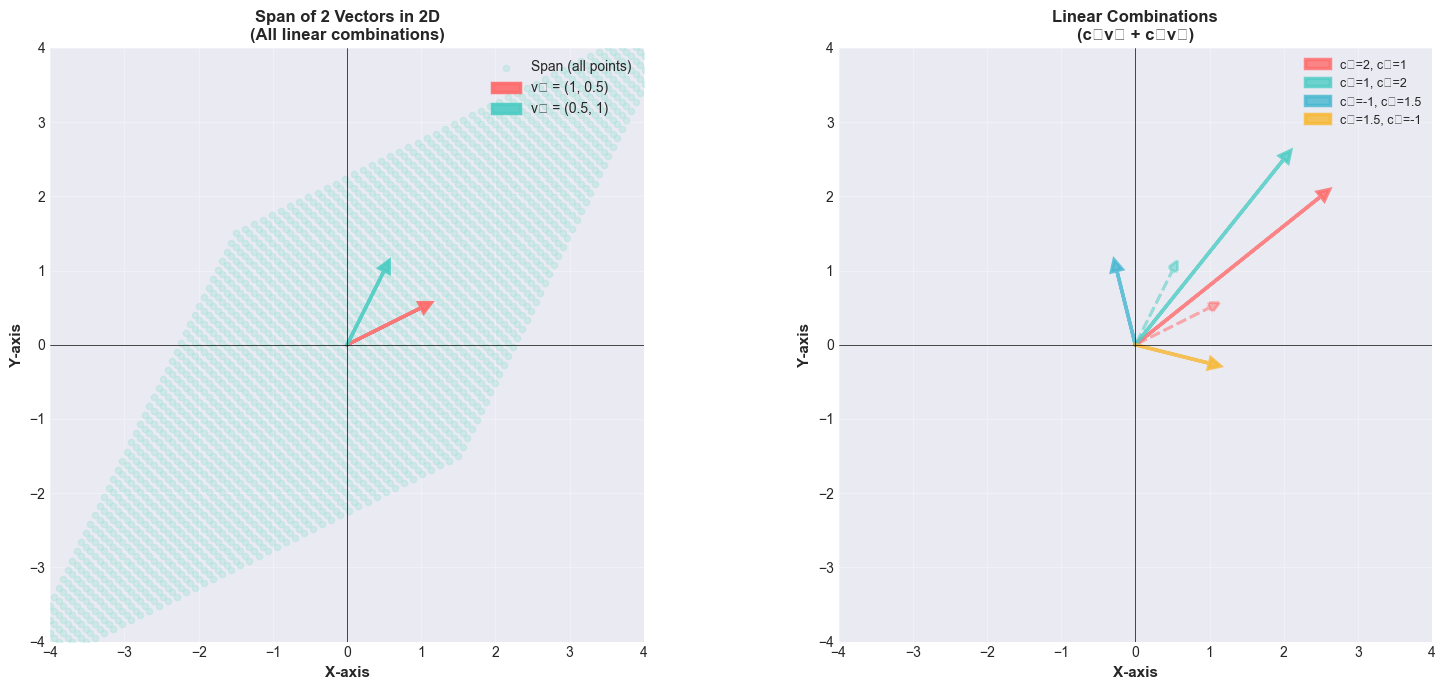

✅ Span of 2 vectors in 2D visualized
   Span covers the entire 2D plane (since v₁ and v₂ are not parallel)


In [17]:
# Visualize span of 2 vectors in 2D
v1 = np.array([1, 0.5])
v2 = np.array([0.5, 1])

# Generate span (all linear combinations)
c_values = np.linspace(-3, 3, 50)
span_points = []

for c1 in c_values:
    for c2 in c_values:
        point = c1 * v1 + c2 * v2
        span_points.append(point)

span_points = np.array(span_points)

# Create 2D span visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Span as scattered points
ax = axes[0]
ax.scatter(span_points[:, 0], span_points[:, 1], alpha=0.3, s=20, color='#95E1D3', label='Span (all points)')
ax.arrow(0, 0, v1[0], v1[1], head_width=0.15, head_length=0.15, 
         fc='#FF6B6B', ec='#FF6B6B', linewidth=2.5, label='v₁ = (1, 0.5)', alpha=0.9)
ax.arrow(0, 0, v2[0], v2[1], head_width=0.15, head_length=0.15, 
         fc='#4ECDC4', ec='#4ECDC4', linewidth=2.5, label='v₂ = (0.5, 1)', alpha=0.9)

ax.grid(True, alpha=0.3)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('X-axis', fontsize=11, fontweight='bold')
ax.set_ylabel('Y-axis', fontsize=11, fontweight='bold')
ax.set_title('Span of 2 Vectors in 2D\n(All linear combinations)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_aspect('equal')

# Plot 2: Show specific linear combinations
ax = axes[1]

# Generate points for different combinations
combinations = [
    (2, 1, '#FF6B6B', 'c₁=2, c₂=1'),
    (1, 2, '#4ECDC4', 'c₁=1, c₂=2'),
    (-1, 1.5, '#45B7D1', 'c₁=-1, c₂=1.5'),
    (1.5, -1, '#F7B731', 'c₁=1.5, c₂=-1'),
]

ax.arrow(0, 0, v1[0], v1[1], head_width=0.15, head_length=0.15, 
         fc='#FF6B6B', ec='#FF6B6B', linewidth=2, alpha=0.5, linestyle='--')
ax.arrow(0, 0, v2[0], v2[1], head_width=0.15, head_length=0.15, 
         fc='#4ECDC4', ec='#4ECDC4', linewidth=2, alpha=0.5, linestyle='--')

for c1, c2, color, label in combinations:
    point = c1 * v1 + c2 * v2
    ax.arrow(0, 0, point[0], point[1], head_width=0.15, head_length=0.15, 
             fc=color, ec=color, linewidth=2.5, label=label, alpha=0.8)

ax.grid(True, alpha=0.3)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('X-axis', fontsize=11, fontweight='bold')
ax.set_ylabel('Y-axis', fontsize=11, fontweight='bold')
ax.set_title('Linear Combinations\n(c₁v₁ + c₂v₂)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("✅ Span of 2 vectors in 2D visualized")
print(f"   Span covers the entire 2D plane (since v₁ and v₂ are not parallel)")

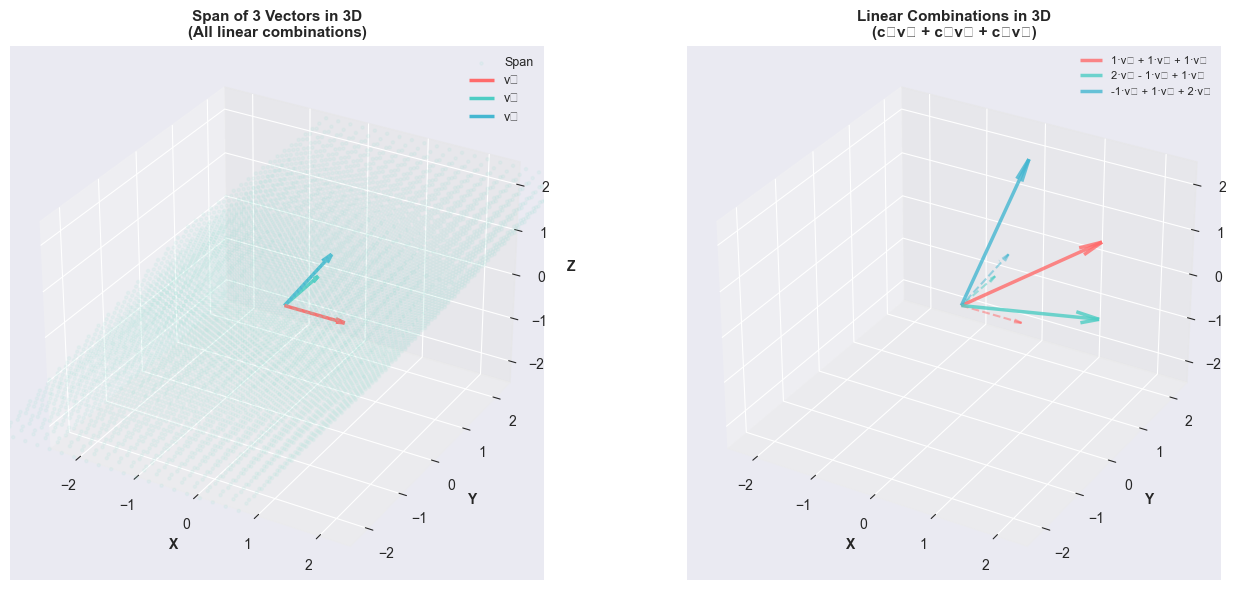

✅ Span of 3 vectors in 3D visualized
   These 3 vectors span the entire 3D space


In [18]:
# Visualize span of 3 vectors in 3D
v1_3d = np.array([1, 0, 0])
v2_3d = np.array([0, 1, 0])
v3_3d = np.array([0.5, 0.5, 1])

# Generate 3D span points
c_values_3d = np.linspace(-2, 2, 20)
span_points_3d = []

for c1 in c_values_3d:
    for c2 in c_values_3d:
        for c3 in c_values_3d:
            point = c1 * v1_3d + c2 * v2_3d + c3 * v3_3d
            span_points_3d.append(point)

span_points_3d = np.array(span_points_3d)

# Create 3D span visualization
fig = plt.figure(figsize=(14, 6))

# Plot 1: 3D span
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(span_points_3d[:, 0], span_points_3d[:, 1], span_points_3d[:, 2], 
           alpha=0.1, s=5, color='#95E1D3', label='Span')

# Plot vectors
ax1.quiver(0, 0, 0, v1_3d[0], v1_3d[1], v1_3d[2], color='#FF6B6B', 
          arrow_length_ratio=0.15, linewidth=2.5, label='v₁')
ax1.quiver(0, 0, 0, v2_3d[0], v2_3d[1], v2_3d[2], color='#4ECDC4', 
          arrow_length_ratio=0.15, linewidth=2.5, label='v₂')
ax1.quiver(0, 0, 0, v3_3d[0], v3_3d[1], v3_3d[2], color='#45B7D1', 
          arrow_length_ratio=0.15, linewidth=2.5, label='v₃')

ax1.set_xlabel('X', fontsize=10, fontweight='bold')
ax1.set_ylabel('Y', fontsize=10, fontweight='bold')
ax1.set_zlabel('Z', fontsize=10, fontweight='bold')
ax1.set_title('Span of 3 Vectors in 3D\n(All linear combinations)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xlim(-2.5, 2.5)
ax1.set_ylim(-2.5, 2.5)
ax1.set_zlim(-2.5, 2.5)

# Plot 2: Specific combinations
ax2 = fig.add_subplot(122, projection='3d')

combinations_3d = [
    (1, 1, 1, '#FF6B6B', '1·v₁ + 1·v₂ + 1·v₃'),
    (2, -1, 1, '#4ECDC4', '2·v₁ - 1·v₂ + 1·v₃'),
    (-1, 1, 2, '#45B7D1', '-1·v₁ + 1·v₂ + 2·v₃'),
]

# Plot vectors
ax2.quiver(0, 0, 0, v1_3d[0], v1_3d[1], v1_3d[2], color='#FF6B6B', 
          arrow_length_ratio=0.15, linewidth=1.5, alpha=0.5, linestyle='--')
ax2.quiver(0, 0, 0, v2_3d[0], v2_3d[1], v2_3d[2], color='#4ECDC4', 
          arrow_length_ratio=0.15, linewidth=1.5, alpha=0.5, linestyle='--')
ax2.quiver(0, 0, 0, v3_3d[0], v3_3d[1], v3_3d[2], color='#45B7D1', 
          arrow_length_ratio=0.15, linewidth=1.5, alpha=0.5, linestyle='--')

for c1, c2, c3, color, label in combinations_3d:
    point = c1 * v1_3d + c2 * v2_3d + c3 * v3_3d
    ax2.quiver(0, 0, 0, point[0], point[1], point[2], color=color, 
              arrow_length_ratio=0.15, linewidth=2.5, label=label, alpha=0.8)

ax2.set_xlabel('X', fontsize=10, fontweight='bold')
ax2.set_ylabel('Y', fontsize=10, fontweight='bold')
ax2.set_zlabel('Z', fontsize=10, fontweight='bold')
ax2.set_title('Linear Combinations in 3D\n(c₁v₁ + c₂v₂ + c₃v₃)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.set_xlim(-2.5, 2.5)
ax2.set_ylim(-2.5, 2.5)
ax2.set_zlim(-2.5, 2.5)

plt.tight_layout()
plt.show()

print("✅ Span of 3 vectors in 3D visualized")
print(f"   These 3 vectors span the entire 3D space")

## Section 5: Scalar Multiplication

**Scalar multiplication** is the multiplication of a vector by a scalar (single number).

### Properties:
- $k \cdot \vec{v}$ scales the magnitude by $|k|$
- If $k > 0$: direction stays same
- If $k < 0$: direction reverses
- If $|k| > 1$: vector gets longer
- If $0 < |k| < 1$: vector gets shorter
- Geometrically: stretches or compresses the vector

### Formula:
$$k \cdot (x, y) = (kx, ky)$$

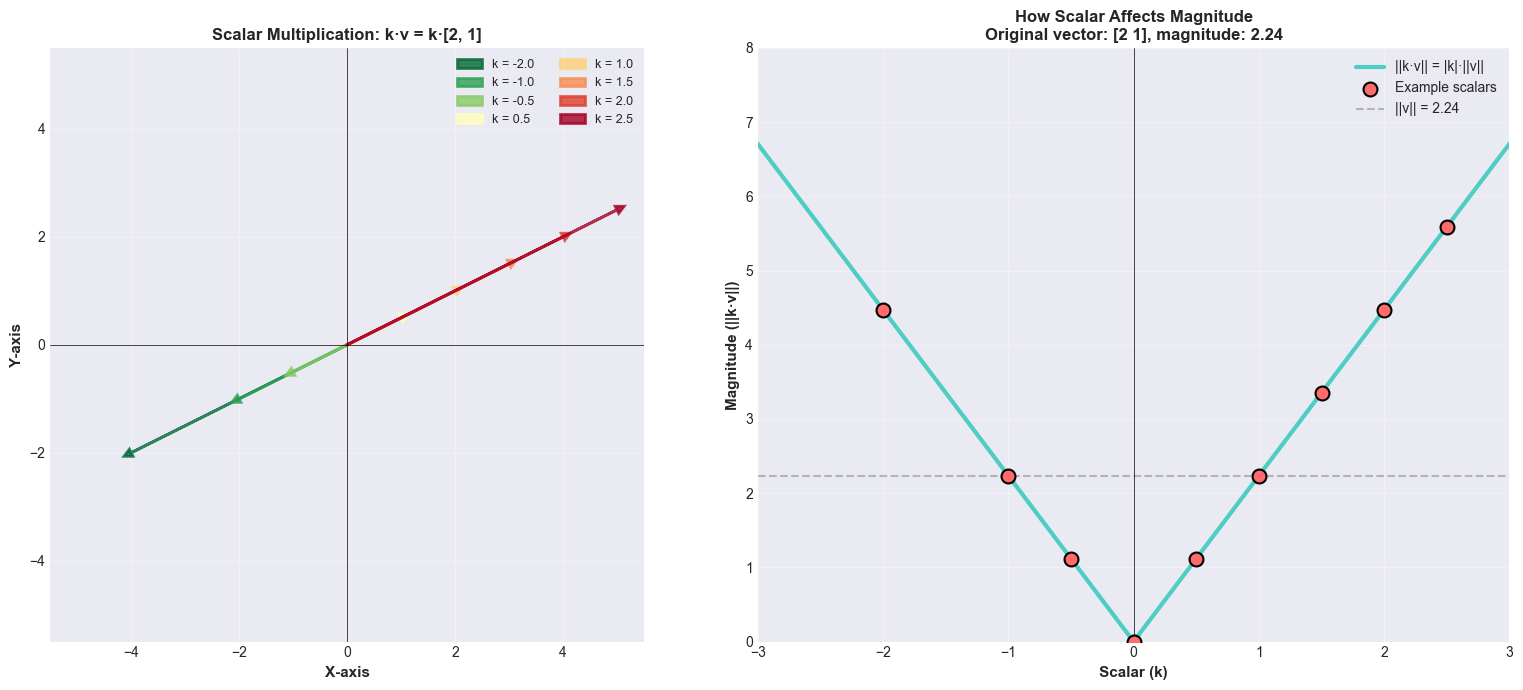

📊 Scalar Multiplication Effects
Original vector: [2 1]
Original magnitude: 2.236

Scalar multiples:
  k = 0.5: 0.5·[2, 1] = [1.0, 0.5] (magnitude: 1.118)
  k =   1: 1·[2, 1] = [2, 1] (magnitude: 2.236)
  k =   2: 2·[2, 1] = [4, 2] (magnitude: 4.472)
  k =  -1: -1·[2, 1] = [-2, -1] (magnitude: 2.236)
  k =  -2: -2·[2, 1] = [-4, -2] (magnitude: 4.472)

✅ Scalar multiplication: stretches or compresses vectors


In [19]:
# Scalar multiplication visualization
v = np.array([2, 1])

# Different scalar values
scalars = np.array([-2, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5])

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Multiple scalar multiples
ax = axes[0]

# Color gradient based on scalar value
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(scalars)))

for scalar, color in zip(scalars, colors):
    scaled_v = scalar * v
    if scalar != 0:
        ax.arrow(0, 0, scaled_v[0], scaled_v[1], head_width=0.15, head_length=0.15, 
                fc=color, ec=color, linewidth=2, alpha=0.8, 
                label=f'k = {scalar}')

# Formatting
ax.grid(True, alpha=0.3)
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-5.5, 5.5)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('X-axis', fontsize=11, fontweight='bold')
ax.set_ylabel('Y-axis', fontsize=11, fontweight='bold')
ax.set_title(f'Scalar Multiplication: k·v = k·{v.tolist()}', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', ncol=2)
ax.set_aspect('equal')

# Plot 2: Show effect of scalar on magnitude
ax = axes[1]

scalar_range = np.linspace(-3, 3, 100)
magnitudes = np.abs(scalar_range) * np.linalg.norm(v)

ax.plot(scalar_range, magnitudes, linewidth=3, color='#4ECDC4', label='||k·v|| = |k|·||v||')
ax.scatter(scalars, np.abs(scalars) * np.linalg.norm(v), s=100, color='#FF6B6B', 
          zorder=5, label='Example scalars', edgecolors='black', linewidth=1.5)

# Add reference line
ax.axhline(y=np.linalg.norm(v), color='gray', linestyle='--', alpha=0.5, label=f'||v|| = {np.linalg.norm(v):.2f}')
ax.axvline(x=0, color='k', linewidth=0.5)

ax.grid(True, alpha=0.3)
ax.set_xlabel('Scalar (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Magnitude (||k·v||)', fontsize=11, fontweight='bold')
ax.set_title(f'How Scalar Affects Magnitude\nOriginal vector: {v}, magnitude: {np.linalg.norm(v):.2f}', 
            fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(-3, 3)
ax.set_ylim(0, 8)

plt.tight_layout()
plt.show()

print("📊 Scalar Multiplication Effects")
print("=" * 60)
print(f"Original vector: {v}")
print(f"Original magnitude: {np.linalg.norm(v):.3f}")
print("\nScalar multiples:")
for scalar in [0.5, 1, 2, -1, -2]:
    scaled_v = scalar * v
    mag = np.linalg.norm(scaled_v)
    print(f"  k = {scalar:>3}: {scalar}·{v.tolist()} = {scaled_v.tolist()} (magnitude: {mag:.3f})")

print("\n✅ Scalar multiplication: stretches or compresses vectors")

## Section 6: Introduction to Derivatives

A **derivative** measures how a function changes as its input changes. It represents the **instantaneous rate of change** at a particular point.

### Definition (Formal):
$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

### Interpretations:
- **Slope** of the tangent line at a point
- **Rate of change** of the function
- **Velocity** if the function represents position
- **Acceleration** if applied to velocity

### Common Derivatives:
- $\frac{d}{dx}(x^n) = nx^{n-1}$ (Power rule)
- $\frac{d}{dx}(\sin x) = \cos x$ (Sine rule)
- $\frac{d}{dx}(e^x) = e^x$ (Exponential rule)

📐 Derivative Calculation Example
Function: f(x) = x²
Analytical derivative: f'(x) = 2x

At x = 2.0:
  Analytical: f'(2.0) = 4.000000
  Numerical:  f'(2.0) = 4.000010
  Difference: 1.00e-05



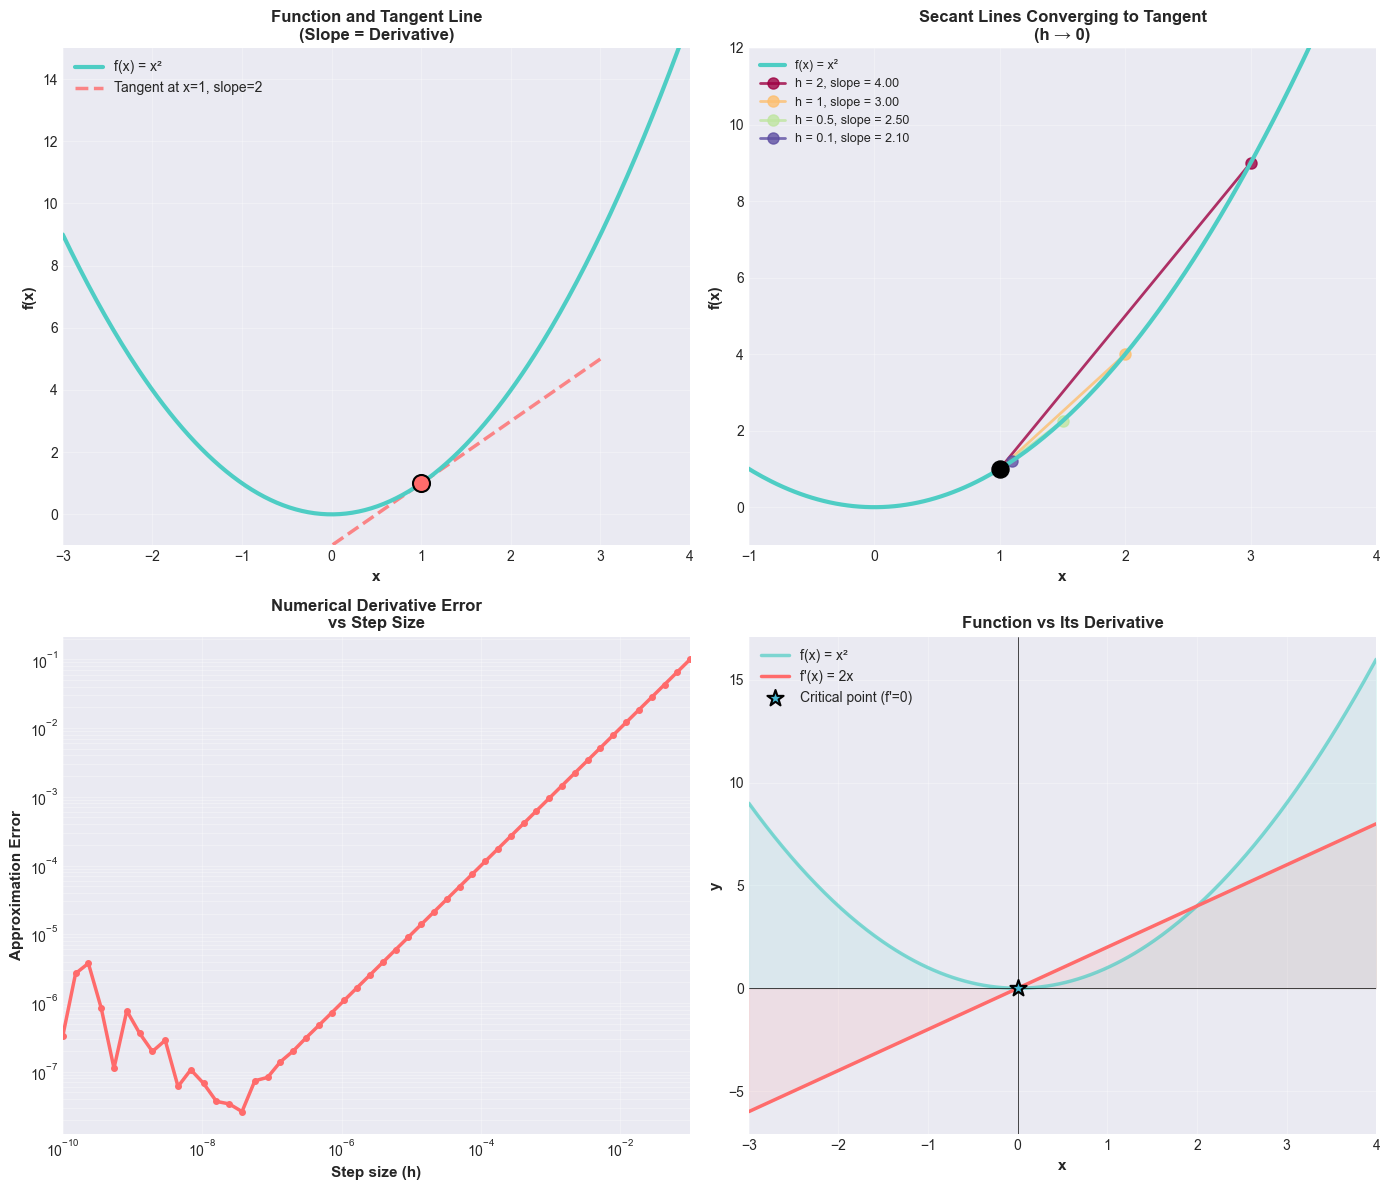

✅ Derivative visualization completed


In [20]:
# Numerical approximation of derivatives
# Using the definition: f'(x) ≈ (f(x+h) - f(x)) / h for small h

def f(x):
    """Example function: f(x) = x^2"""
    return x**2

def f_derivative_analytical(x):
    """Analytical derivative: f'(x) = 2x"""
    return 2 * x

def f_derivative_numerical(x, h=1e-5):
    """Numerical derivative using limit definition"""
    return (f(x + h) - f(x)) / h

# Test point
x_test = 2.0

# Compare analytical and numerical
analytical = f_derivative_analytical(x_test)
numerical = f_derivative_numerical(x_test)

print("📐 Derivative Calculation Example")
print("=" * 60)
print(f"Function: f(x) = x²")
print(f"Analytical derivative: f'(x) = 2x")
print()
print(f"At x = {x_test}:")
print(f"  Analytical: f'({x_test}) = {analytical:.6f}")
print(f"  Numerical:  f'({x_test}) = {numerical:.6f}")
print(f"  Difference: {abs(analytical - numerical):.2e}")
print()

# Visualization of the derivative concept
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Function and tangent line at different h values
ax = axes[0, 0]

x = np.linspace(-3, 4, 300)
y = f(x)

ax.plot(x, y, linewidth=3, color='#4ECDC4', label='f(x) = x²', zorder=3)

# Show tangent line at x = 1
x_point = 1
y_point = f(x_point)
slope = f_derivative_analytical(x_point)

x_tangent = np.linspace(-1, 3, 100)
y_tangent = y_point + slope * (x_tangent - x_point)

ax.plot(x_tangent, y_tangent, linewidth=2.5, color='#FF6B6B', 
        linestyle='--', label=f"Tangent at x={x_point}, slope={slope}", alpha=0.8)
ax.scatter([x_point], [y_point], s=150, color='#FF6B6B', zorder=5, edgecolors='black', linewidth=1.5)

ax.grid(True, alpha=0.3)
ax.set_xlabel('x', fontsize=11, fontweight='bold')
ax.set_ylabel('f(x)', fontsize=11, fontweight='bold')
ax.set_title('Function and Tangent Line\n(Slope = Derivative)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(-3, 4)
ax.set_ylim(-1, 15)

# Plot 2: Showing secant lines for different h values
ax = axes[0, 1]

ax.plot(x, y, linewidth=3, color='#4ECDC4', label='f(x) = x²', zorder=3)

x_point = 1
y_point = f(x_point)

h_values = [2, 1, 0.5, 0.1]
colors_h = plt.cm.Spectral(np.linspace(0, 1, len(h_values)))

for h, color in zip(h_values, colors_h):
    x_next = x_point + h
    y_next = f(x_next)
    slope = (y_next - y_point) / h
    
    x_secant = np.array([x_point, x_next])
    y_secant = np.array([y_point, y_next])
    
    ax.plot(x_secant, y_secant, linewidth=2, color=color, 
            marker='o', markersize=8, label=f'h = {h}, slope = {slope:.2f}', alpha=0.8)

ax.scatter([x_point], [y_point], s=150, color='black', zorder=5, marker='o')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x', fontsize=11, fontweight='bold')
ax.set_ylabel('f(x)', fontsize=11, fontweight='bold')
ax.set_title('Secant Lines Converging to Tangent\n(h → 0)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 12)

# Plot 3: Numerical derivative approximation error
ax = axes[1, 0]

h_range = np.logspace(-10, -1, 50)
errors = []

for h in h_range:
    numerical_approx = (f(x_test + h) - f(x_test)) / h
    error = abs(numerical_approx - analytical)
    errors.append(error)

ax.loglog(h_range, errors, linewidth=2.5, color='#FF6B6B', marker='o', markersize=4)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlabel('Step size (h)', fontsize=11, fontweight='bold')
ax.set_ylabel('Approximation Error', fontsize=11, fontweight='bold')
ax.set_title('Numerical Derivative Error\nvs Step Size', fontsize=12, fontweight='bold')
ax.set_xlim(1e-10, 1e-1)

# Plot 4: Function and its derivative
ax = axes[1, 1]

x_deriv = np.linspace(-3, 4, 300)
y_deriv = f_derivative_analytical(x_deriv)

ax.plot(x, y, linewidth=2.5, color='#4ECDC4', label="f(x) = x²", alpha=0.7)
ax.plot(x_deriv, y_deriv, linewidth=2.5, color='#FF6B6B', label="f'(x) = 2x")

ax.fill_between(x, 0, y, alpha=0.1, color='#4ECDC4')
ax.fill_between(x_deriv, 0, y_deriv, alpha=0.1, color='#FF6B6B')

# Mark critical point
ax.scatter([0], [0], s=150, color='#45B7D1', zorder=5, marker='*', 
          label='Critical point (f\'=0)', edgecolors='black', linewidth=1.5)

ax.grid(True, alpha=0.3)
ax.set_xlabel('x', fontsize=11, fontweight='bold')
ax.set_ylabel('y', fontsize=11, fontweight='bold')
ax.set_title('Function vs Its Derivative', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(-3, 4)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("✅ Derivative visualization completed")

## Section 7: Visualizing Derivatives (Tangent Lines)

The tangent line at a point on a curve has a slope equal to the derivative at that point. This represents the instantaneous rate of change.

### Visualization Approach:
- Plot the original function
- Draw tangent lines at multiple points
- Show how the slope (derivative) changes along the curve
- Demonstrate relationship between function and its derivative

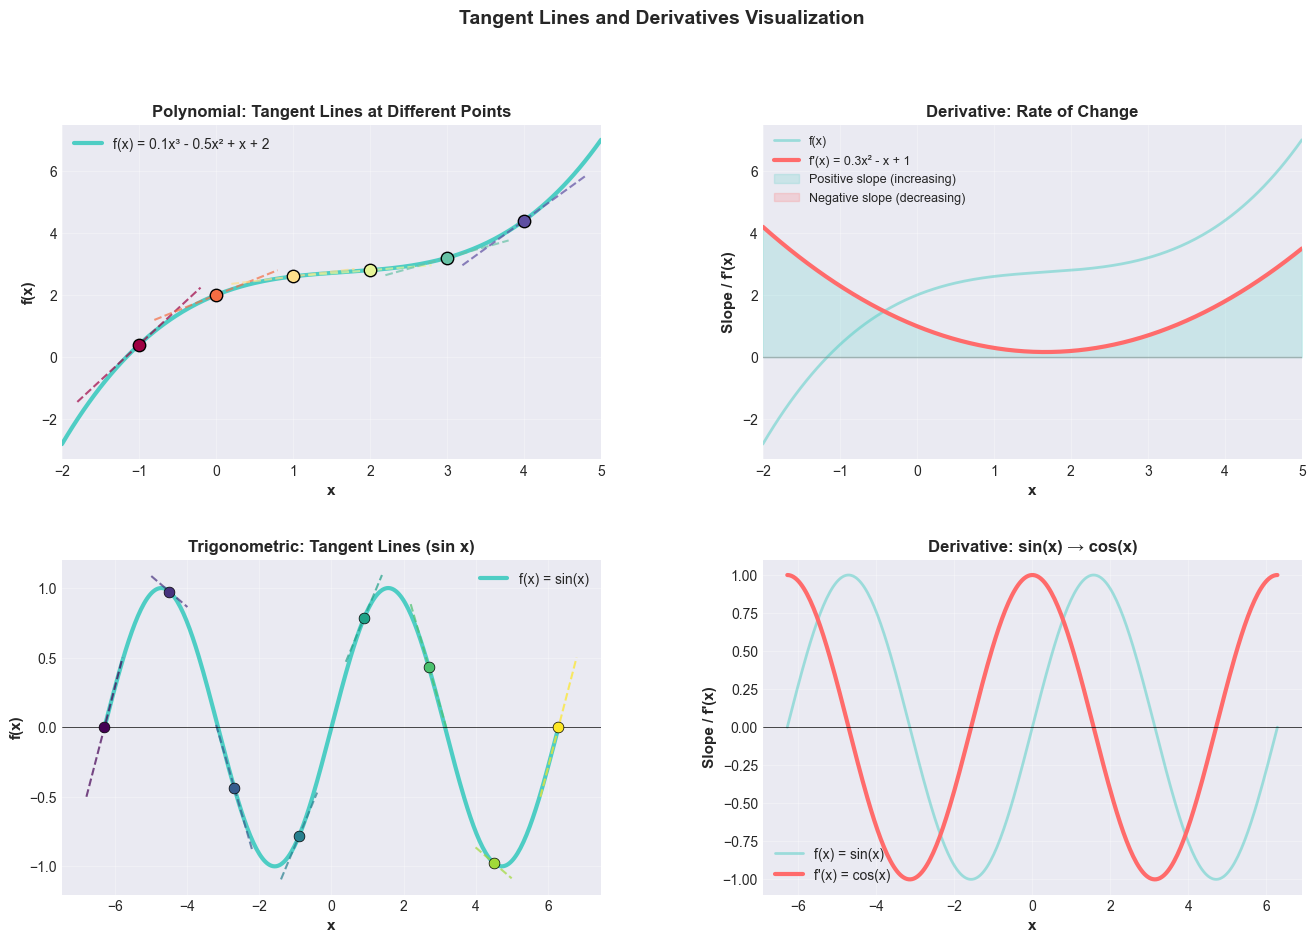

✅ Tangent line visualizations completed

Key Observations:
  • Tangent line slope = derivative value at that point
  • Where derivative > 0: function is increasing
  • Where derivative < 0: function is decreasing
  • Where derivative = 0: critical points (local max/min)
  • Derivative shows how fast the function is changing


In [21]:
# Example 1: Polynomial function with tangent lines
def poly_func(x):
    return 0.1*x**3 - 0.5*x**2 + x + 2

def poly_derivative(x):
    return 0.3*x**2 - x + 1

# Example 2: Trigonometric function
def trig_func(x):
    return np.sin(x)

def trig_derivative(x):
    return np.cos(x)

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Plot 1: Polynomial with tangent lines
ax1 = fig.add_subplot(gs[0, 0])
x_range = np.linspace(-2, 5, 300)
y_poly = poly_func(x_range)

ax1.plot(x_range, y_poly, linewidth=3, color='#4ECDC4', label='f(x) = 0.1x³ - 0.5x² + x + 2', zorder=2)

# Add tangent lines at multiple points
x_tangent_points = np.linspace(-1, 4, 6)
colors_tangent = plt.cm.Spectral(np.linspace(0, 1, len(x_tangent_points)))

for x_t, color in zip(x_tangent_points, colors_tangent):
    y_t = poly_func(x_t)
    slope_t = poly_derivative(x_t)
    
    x_line = np.linspace(x_t - 0.8, x_t + 0.8, 100)
    y_line = y_t + slope_t * (x_line - x_t)
    
    ax1.plot(x_line, y_line, linewidth=1.5, color=color, linestyle='--', alpha=0.7)
    ax1.scatter([x_t], [y_t], s=80, color=color, zorder=5, edgecolors='black', linewidth=1)

ax1.grid(True, alpha=0.3)
ax1.set_xlabel('x', fontsize=11, fontweight='bold')
ax1.set_ylabel('f(x)', fontsize=11, fontweight='bold')
ax1.set_title('Polynomial: Tangent Lines at Different Points', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(-2, 5)

# Plot 2: Derivative of polynomial
ax2 = fig.add_subplot(gs[0, 1])
x_deriv_poly = np.linspace(-2, 5, 300)
y_deriv_poly = poly_derivative(x_deriv_poly)

ax2.plot(x_range, y_poly, linewidth=2, color='#4ECDC4', alpha=0.5, label='f(x)')
ax2.plot(x_deriv_poly, y_deriv_poly, linewidth=3, color='#FF6B6B', label="f'(x) = 0.3x² - x + 1")
ax2.axhline(y=0, color='gray', linewidth=1, linestyle='-', alpha=0.5)
ax2.fill_between(x_deriv_poly, 0, y_deriv_poly, where=(y_deriv_poly >= 0), 
                 alpha=0.2, color='#4ECDC4', label='Positive slope (increasing)')
ax2.fill_between(x_deriv_poly, 0, y_deriv_poly, where=(y_deriv_poly < 0), 
                 alpha=0.2, color='#FF6B6B', label='Negative slope (decreasing)')

ax2.grid(True, alpha=0.3)
ax2.set_xlabel('x', fontsize=11, fontweight='bold')
ax2.set_ylabel('Slope / f\'(x)', fontsize=11, fontweight='bold')
ax2.set_title('Derivative: Rate of Change', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlim(-2, 5)

# Plot 3: Trigonometric function with tangent lines
ax3 = fig.add_subplot(gs[1, 0])
x_range_trig = np.linspace(-2*np.pi, 2*np.pi, 300)
y_trig = trig_func(x_range_trig)

ax3.plot(x_range_trig, y_trig, linewidth=3, color='#4ECDC4', label='f(x) = sin(x)', zorder=2)

# Add tangent lines
x_tangent_trig = np.linspace(-2*np.pi, 2*np.pi, 8)
colors_tangent_trig = plt.cm.viridis(np.linspace(0, 1, len(x_tangent_trig)))

for x_t, color in zip(x_tangent_trig, colors_tangent_trig):
    y_t = trig_func(x_t)
    slope_t = trig_derivative(x_t)
    
    x_line = np.linspace(x_t - 0.5, x_t + 0.5, 100)
    y_line = y_t + slope_t * (x_line - x_t)
    
    ax3.plot(x_line, y_line, linewidth=1.5, color=color, linestyle='--', alpha=0.7)
    ax3.scatter([x_t], [y_t], s=60, color=color, zorder=5, edgecolors='black', linewidth=0.5)

ax3.grid(True, alpha=0.3)
ax3.set_xlabel('x', fontsize=11, fontweight='bold')
ax3.set_ylabel('f(x)', fontsize=11, fontweight='bold')
ax3.set_title('Trigonometric: Tangent Lines (sin x)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.axhline(y=0, color='k', linewidth=0.5)

# Plot 4: Derivative of trigonometric
ax4 = fig.add_subplot(gs[1, 1])
x_deriv_trig = np.linspace(-2*np.pi, 2*np.pi, 300)
y_deriv_trig = trig_derivative(x_deriv_trig)

ax4.plot(x_range_trig, y_trig, linewidth=2, color='#4ECDC4', alpha=0.5, label='f(x) = sin(x)')
ax4.plot(x_deriv_trig, y_deriv_trig, linewidth=3, color='#FF6B6B', label="f'(x) = cos(x)")

ax4.grid(True, alpha=0.3)
ax4.set_xlabel('x', fontsize=11, fontweight='bold')
ax4.set_ylabel('Slope / f\'(x)', fontsize=11, fontweight='bold')
ax4.set_title('Derivative: sin(x) → cos(x)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.axhline(y=0, color='k', linewidth=0.5)

plt.suptitle('Tangent Lines and Derivatives Visualization', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("✅ Tangent line visualizations completed")
print("\nKey Observations:")
print("  • Tangent line slope = derivative value at that point")
print("  • Where derivative > 0: function is increasing")
print("  • Where derivative < 0: function is decreasing")
print("  • Where derivative = 0: critical points (local max/min)")
print("  • Derivative shows how fast the function is changing")

## Summary: Key Concepts

### 🔹 Vectors
- Quantities with magnitude and direction
- Can be 2D, 3D, or n-dimensional
- Magnitude: $||\vec{v}|| = \sqrt{x^2 + y^2 + z^2 + ...}$
- Operations: addition, subtraction, scalar multiplication

### 🔹 Unit Vectors
- Vectors with magnitude exactly 1
- Formula: $\hat{v} = \frac{\vec{v}}{||\vec{v}||}$
- Represent pure direction
- Basis for coordinate systems

### 🔹 Span of Vectors
- All possible linear combinations: $c_1\vec{v_1} + c_2\vec{v_2} + ...$
- 1 vector: line through origin
- 2 non-parallel vectors: plane through origin
- 3 non-coplanar vectors: 3D space

### 🔹 Scalar Multiplication
- Multiplying vector by scalar $k$: $k\vec{v} = (kx, ky, ...)$
- Scales magnitude by $|k|$, preserves/reverses direction
- $k > 1$: lengthens, $0 < k < 1$: shortens, $k < 0$: reverses

### 🔹 Derivatives
- Rate of change of a function
- Formula: $f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$
- Geometrically: slope of tangent line
- Positive derivative: function increasing
- Negative derivative: function decreasing
- Zero derivative: critical point

### 📚 Applications
- **Vectors**: Physics (forces), computer graphics, machine learning
- **Unit vectors**: Normalization, coordinate systems
- **Span**: Basis determination, linear independence
- **Scalars**: Scaling operations, weights
- **Derivatives**: Optimization, machine learning (gradient descent)